# 🏆 Обучение ConvNeXt-Tiny: Двухфазное расписание, Multi-Task признаки и 3-Уровневая калибровка
### Пайплайн глубокого обучения на GPU для достижения минимального MAE (~6.00 п.п.)

Ключевые инженерные решения:
1. **Архитектура ConvNeXt-Tiny**:
   - Глубинные свёртки 7×7, инвертированные bottleneck-блоки, LayerNorm, GELU.
   - Вектор признаков: 768 измерений.
2. **Многозадачное обучение (Multi-Task Learning)**:
   - `dist_head`: распределение вероятностей по 21 бину (0, 5, ..., 100%) + матожидание;
   - `load_bin_head`: вспомогательная классификация 10 диапазонов загрузки;
   - `cargo_type_head`: классификация 5 категорий груза (паллеты, коробки, контейнеры и др.).
3. **Двухфазное обучение с адаптивным LR**:
   - **Фаза 1 (5 эпох)**: Backbone заморожен, прогрев голов (`head_lr = 8e-4`, AdamW, weight decay 0.01).
   - **Фаза 2 (18 эпох)**: Разморозка всей сети (`backbone_lr = 5e-5`, `head_lr = 2e-4`, CosineAnnealingLR down to 1e-6, Gradient Clipping 1.0).
4. **3-Уровневая калибровка**:
   - Level 1: **TTA** (Test-Time Augmentation горизонтальным отражением);
   - Level 2: **Boundary Clamping** (пороговое отсечение шума на пустых $\le 3.5\% \to 0.0\%$ и полных $\ge 94.5\% \to 100.0\%$ фурах);
   - Level 3: **Аффинная калибровка** $a \cdot \hat{y} + b$ по Out-Of-Fold валидации.
5. **Стэкинг с геометрией (опционально)**: синергия с признаками свободного пола и видимого потолка.

In [1]:
# 1. Проверка GPU и установка необходимых библиотек
import os
import sys
import time
import json
import shutil
from pathlib import Path

import torch
import numpy as np
import pandas as pd

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Устройство для вычислений: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Доступно видеопамяти: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
else:
    print("ВНИМАНИЕ: Обучение запущено на CPU. Рекомендуется включить GPU T4/P100 в панели настроек Kaggle!")

!pip install -q albumentations timm segmentation-models-pytorch pandas opencv-python-headless scikit-learn matplotlib seaborn

Устройство для вычислений: cuda
GPU: Tesla T4
Доступно видеопамяти: 14.56 GB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 1.2 MB/s eta 0:00:00a 0:00:01


In [2]:
# 2. Конфигурация ConvNeXt-Tiny и гиперпараметры обучения
# ==============================================================================
BACKBONE_NAME = "convnext_tiny"
IMG_SIZE = 384             # Разрешение входа 384x384 (на 44% больше деталей в глубине фуры)
BATCH_SIZE = 16            # Оптимальный размер батча для стабильного обучения ConvNeXt
NUM_WORKERS = 4            # Потоки загрузчика DataLoader

# Расписание фаз:
PHASE1_EPOCHS = 4          # Фаза 1: прогрев голов (backbone заморожен, 4 эпохи достаточно)
PHASE2_EPOCHS = 20         # Фаза 2: тонкая доводка всей сети с плавным CosineAnnealing
PATIENCE = 8               # Запас терпения для сходимости на 384x384

# Learning Rates и регуляризация:
PHASE1_HEAD_LR = 8e-4      # LR для голов в Фазе 1
PHASE2_BACKBONE_LR = 6e-5  # Оптимальный LR для ConvNeXt на 384x384
PHASE2_HEAD_LR = 2.5e-4    # LR для голов в Фазе 2
WEIGHT_DECAY = 1e-2        # L2-регуляризация для AdamW
GRAD_CLIP = 1.0            # Максимальная норма градиента (защита от выбросов)

# Веса вспомогательных лоссов:
DIST_WEIGHT = 0.5          # Вес вероятностного лосса 21 бина
AUX_WEIGHT = 0.2           # Вес классификаторов (load_bin + cargo_type)
USE_AMP = (DEVICE == "cuda")  # Смешанная точность FP16
# ==============================================================================

KAGGLE_INPUT = Path("/kaggle/input")
WORK_DIR = Path("/kaggle/working")
MODELS_DIR = WORK_DIR / "models" / "convnext_v1"
OUTPUT_DIR = WORK_DIR / "output_csv"

for d in (MODELS_DIR, OUTPUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Поиск путей к датасету
folds_candidates = list(KAGGLE_INPUT.rglob("folds.csv"))
if not folds_candidates:
    raise FileNotFoundError("Файл folds.csv не найден в /kaggle/input!")
FOLDS_CSV = folds_candidates[0]
DATASET_ROOT = FOLDS_CSV.parent.parent.parent

TRAIN_IMAGES = DATASET_ROOT / "DataSet/train/images"
TEST_CSV = DATASET_ROOT / "DataSet/test/test.csv"
TEST_IMAGES = DATASET_ROOT / "DataSet/test/images"

print(f"Датасет найден: {DATASET_ROOT}")
print(f"Таблица фолдов: {FOLDS_CSV}")
print(f"Папка train фото: {TRAIN_IMAGES}")
print(f"Тестовая таблица: {TEST_CSV}")

Датасет найден: /kaggle/input/datasets/kirillpovasin/zxczxc
Таблица фолдов: /kaggle/input/datasets/kirillpovasin/zxczxc/DataSet/train/folds.csv
Папка train фото: /kaggle/input/datasets/kirillpovasin/zxczxc/DataSet/train/images
Тестовая таблица: /kaggle/input/datasets/kirillpovasin/zxczxc/DataSet/test/test.csv


In [3]:
# 3. Самодостаточная реализация Dataset и ConvNeXt-Tiny с multi-task головами
import cv2
from PIL import Image, ImageOps
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import timm

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
NUM_PERCENT_BINS = 21

LOAD_BIN_MAP = {
    '0-10': 0, '10-20': 1, '20-30': 2, '30-40': 3, '40-50': 4,
    '50-60': 5, '60-70': 6, '70-80': 7, '80-90': 8, '90-100': 9,
}
CARGO_TYPE_MAP = {
    'blue_open_containers': 0,
    'pallets': 1,
    'blue_full_container': 2,
    'boxes': 3,
    'mixed': 4,
}

def read_rgb_image(path):
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img)
        if img.mode != "RGB":
            img = img.convert("RGB")
        return np.array(img, dtype=np.uint8)

def letterbox_transforms(img_size):
    return [
        A.LongestMaxSize(max_size=img_size),
        A.PadIfNeeded(
            min_height=img_size,
            min_width=img_size,
            border_mode=cv2.BORDER_CONSTANT,
            value=(0, 0, 0),
        ),
    ]

def build_transforms(train, img_size):
    if not train:
        return A.Compose(
            letterbox_transforms(img_size)
            + [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
        )
    return A.Compose(
        letterbox_transforms(img_size)
        + [
            A.HorizontalFlip(p=0.5),
            A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=0.6),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
            A.RandomGamma(gamma_limit=(65, 145), p=0.6),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.4),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.08, rotate_limit=5, border_mode=cv2.BORDER_CONSTANT, fill=(0, 0, 0), p=0.5),
            A.CoarseDropout(num_holes_range=(1, 3), hole_height_range=(int(img_size * 0.1), int(img_size * 0.3)), hole_width_range=(int(img_size * 0.05), int(img_size * 0.15)), fill=0, p=0.35),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]
    )

def build_clahe_transform(img_size):
    return A.Compose(
        [A.CLAHE(clip_limit=3.0, tile_grid_size=(8, 8), p=1.0)]
        + letterbox_transforms(img_size)
        + [A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD), ToTensorV2()]
    )

class TruckDataset(Dataset):
    def __init__(self, rows, image_dir, img_size, train=True):
        self.rows = rows
        self.image_dir = Path(image_dir)
        self.transform = build_transforms(train=train, img_size=img_size)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, idx):
        row = self.rows[idx]
        img = read_rgb_image(self.image_dir / f"{row['image_id']}.jpg")
        tensor = self.transform(image=img)["image"]
        return {
            "image": tensor,
            "load_pct": torch.tensor(float(row["load_pct"]), dtype=torch.float32),
            "load_bin": torch.tensor(LOAD_BIN_MAP.get(str(row["load_bin"]), 0), dtype=torch.long),
            "cargo_type": torch.tensor(CARGO_TYPE_MAP.get(str(row["cargo_type"]), 0), dtype=torch.long),
            "image_id": row["image_id"],
        }

def get_soft_targets(y, num_bins=NUM_PERCENT_BINS, smoothing=0.01):
    step = 100.0 / (num_bins - 1)
    y_clamped = torch.clamp(y, 0.0, 100.0)
    idx_low = torch.clamp((y_clamped / step).long(), 0, num_bins - 2)
    idx_high = idx_low + 1
    alpha = (y_clamped - idx_low.float() * step) / step
    targets = torch.zeros(len(y), num_bins, device=y.device)
    targets.scatter_add_(1, idx_low.unsqueeze(1), (1.0 - alpha).unsqueeze(1))
    targets.scatter_add_(1, idx_high.unsqueeze(1), alpha.unsqueeze(1))
    if smoothing > 0:
        targets = (1.0 - smoothing) * targets + (smoothing / num_bins)
    return targets

class ConvNeXtTruckNet(nn.Module):
    def __init__(self, backbone_name="convnext_tiny", pretrained=True, dropout=0.3):
        super().__init__()
        self.register_buffer("bin_centers", torch.linspace(0, 100, NUM_PERCENT_BINS))
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0, global_pool="avg")
        feat_dim = self.backbone.num_features
        self.dropout = nn.Dropout(dropout)
        self.dist_head = nn.Linear(feat_dim, NUM_PERCENT_BINS)
        self.regression_head = nn.Linear(feat_dim, 1)
        self.load_bin_head = nn.Linear(feat_dim, len(LOAD_BIN_MAP))
        self.cargo_type_head = nn.Linear(feat_dim, len(CARGO_TYPE_MAP))
        self._backbone_trainable = True

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.dropout(feat)
        dist_logits = self.dist_head(feat)
        dist_probs = torch.softmax(dist_logits, dim=-1)
        exp_pct = torch.sum(dist_probs * self.bin_centers.to(dist_probs.device), dim=-1)
        bin_logits = self.load_bin_head(feat)
        cargo_logits = self.cargo_type_head(feat)
        return exp_pct, bin_logits, cargo_logits, dist_logits

    def set_backbone_trainable(self, trainable):
        for p in self.backbone.parameters():
            p.requires_grad = trainable
        self._backbone_trainable = trainable
        self.backbone.train(self.training and trainable)

    def train(self, mode=True):
        super().train(mode)
        if not self._backbone_trainable:
            self.backbone.eval()
        return self

print("✓ Архитектура ConvNeXt-Tiny и пайплайн загрузки успешно инициализированы!")

✓ Архитектура ConvNeXt-Tiny и пайплайн загрузки успешно инициализированы!


In [4]:
# 4. Двухфазное обучение 4 фолдов ConvNeXt-Tiny
def run_epoch(model, loader, optimizer, scaler, device, train=True):
    model.train(mode=train)
    total_loss = 0.0
    all_targets, all_preds = [], []
    reg_loss_fn = nn.L1Loss()
    ce_loss_fn = nn.CrossEntropyLoss()

    with torch.set_grad_enabled(train):
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            load_pct = batch["load_pct"].to(device, non_blocking=True)
            load_bin = batch["load_bin"].to(device, non_blocking=True)
            cargo_type = batch["cargo_type"].to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda" if device == "cuda" else "cpu", enabled=(scaler is not None)):
                pred_pct, bin_logits, cargo_logits, dist_logits = model(images)
                loss_reg = reg_loss_fn(pred_pct, load_pct)
                soft_t = get_soft_targets(load_pct)
                loss_dist = nn.functional.cross_entropy(dist_logits, soft_t)
                loss_aux = ce_loss_fn(bin_logits, load_bin) + ce_loss_fn(cargo_logits, cargo_type)
                loss = loss_reg + DIST_WEIGHT * loss_dist + AUX_WEIGHT * loss_aux

            if train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    if GRAD_CLIP > 0:
                        scaler.unscale_(optimizer)
                        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    if GRAD_CLIP > 0:
                        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                    optimizer.step()

            total_loss += float(loss.detach()) * len(load_pct)
            all_targets.extend(load_pct.detach().cpu().numpy().tolist())
            all_preds.extend(pred_pct.detach().cpu().numpy().tolist())

    mean_mae = float(np.mean(np.abs(np.array(all_targets) - np.array(all_preds))))
    return total_loss / len(all_targets), mean_mae

def train_fold(fold_idx, df_folds):
    train_df = df_folds[df_folds["fold"] != fold_idx]
    val_df = df_folds[df_folds["fold"] == fold_idx]

    train_ds = TruckDataset(train_df.to_dict("records"), TRAIN_IMAGES, IMG_SIZE, train=True)
    val_ds = TruckDataset(val_df.to_dict("records"), TRAIN_IMAGES, IMG_SIZE, train=False)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    print(f"\n{'='*55}")
    print(f"🚀 СТАРТ ОБУЧЕНИЯ [FOLD {fold_idx}] (Train: {len(train_ds)}, Val: {len(val_ds)})")
    print(f"{'='*55}")

    model = ConvNeXtTruckNet(BACKBONE_NAME, pretrained=True).to(DEVICE)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

    # Фаза 1: прогрев голов
    model.set_backbone_trainable(False)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=PHASE1_HEAD_LR, weight_decay=WEIGHT_DECAY)
    scheduler = None

    best_val_mae = float("inf")
    best_weights = None
    no_improve = 0
    total_epochs = PHASE1_EPOCHS + PHASE2_EPOCHS

    for epoch in range(total_epochs):
        # Переход в Фазу 2
        if epoch == PHASE1_EPOCHS:
            print(f"\n🔓 [FOLD {fold_idx}] Разморозка всей сети (Фаза 2: Fine-Tuning с CosineAnnealing)...\n")
            model.set_backbone_trainable(True)
            head_params = list(model.dist_head.parameters()) + list(model.regression_head.parameters()) + list(model.load_bin_head.parameters()) + list(model.cargo_type_head.parameters())
            optimizer = torch.optim.AdamW([
                {"params": model.backbone.parameters(), "lr": PHASE2_BACKBONE_LR},
                {"params": head_params, "lr": PHASE2_HEAD_LR},
            ], weight_decay=WEIGHT_DECAY)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=PHASE2_EPOCHS, eta_min=1e-6)

        t0 = time.time()
        tr_loss, tr_mae = run_epoch(model, train_loader, optimizer, scaler if USE_AMP else None, DEVICE, train=True)
        vl_loss, vl_mae = run_epoch(model, val_loader, optimizer=None, scaler=None, device=DEVICE, train=False)
        if scheduler is not None:
            scheduler.step()
        dt = time.time() - t0

        phase_tag = "P1 (Warmup)" if epoch < PHASE1_EPOCHS else "P2 (FineTune)"
        lr_now = optimizer.param_groups[0]['lr']
        mark = ""
        if vl_mae < best_val_mae:
            best_val_mae = vl_mae
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
            mark = f"⭐ (BEST {best_val_mae:.2f})"
        else:
            no_improve += 1

        print(f"[Fold {fold_idx} | {phase_tag}] Ep {epoch+1:02d}/{total_epochs:02d} | LR: {lr_now:.1e} | Train MAE: {tr_mae:5.2f} | Val MAE: {vl_mae:5.2f} {mark} ({dt:.1f}s)")

        if no_improve >= PATIENCE and epoch >= PHASE1_EPOCHS + 5:
            print(f"⏹️ Ранняя остановка на эпохе {epoch+1}!")
            break

    ckpt_path = MODELS_DIR / f"fold{fold_idx}_best.pt"
    torch.save({
        "model_state_dict": best_weights,
        "backbone": BACKBONE_NAME,
        "img_size": IMG_SIZE,
        "val_mae": best_val_mae,
    }, ckpt_path)
    print(f"✓ Чекпоинт фолда {fold_idx} сохранён: {ckpt_path.name} (Val MAE: {best_val_mae:.4f})")
    return best_val_mae

# Запуск обучения всех 4 фолдов
df_folds = pd.read_csv(FOLDS_CSV)
fold_maes = {}
start_total = time.time()

for f in sorted(df_folds["fold"].unique()):
    fold_maes[f] = train_fold(f, df_folds)

elapsed_total = (time.time() - start_total) / 60
mean_mae = np.mean(list(fold_maes.values()))
std_mae = np.std(list(fold_maes.values()))

print(f"\n{'='*60}")
print(f"🎉 ОБУЧЕНИЕ 4 ФОЛДОВ CONVNEXT-TINY ЗАВЕРШЕНО ЗА {elapsed_total:.1f} МИН!")
print(f"{'='*60}")
for f, score in fold_maes.items():
    print(f"   Fold {f}: Val MAE = {score:.4f} п.п.")
print(f"   Средний Val MAE: {mean_mae:.4f} ± {std_mae:.4f} п.п.")
print(f"{'='*60}")


🚀 СТАРТ ОБУЧЕНИЯ [FOLD 0] (Train: 537, Val: 179)


/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/tmp/ipykernel_58/2836239667.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[Fold 0 | P1 (Warmup)] Ep 01/24 | LR: 8.0e-04 | Train MAE: 22.05 | Val MAE: 13.64 ⭐ (BEST 13.64) (20.5s)
[Fold 0 | P1 (Warmup)] Ep 02/24 | LR: 8.0e-04 | Train MAE: 13.08 | Val MAE: 12.56 ⭐ (BEST 12.56) (10.1s)
[Fold 0 | P1 (Warmup)] Ep 03/24 | LR: 8.0e-04 | Train MAE: 11.72 | Val MAE: 12.06 ⭐ (BEST 12.06) (9.9s)
[Fold 0 | P1 (Warmup)] Ep 04/24 | LR: 8.0e-04 | Train MAE: 10.98 | Val MAE: 10.97 ⭐ (BEST 10.97) (10.0s)

🔓 [FOLD 0] Разморозка всей сети (Фаза 2: Fine-Tuning с CosineAnnealing)...

[Fold 0 | P2 (FineTune)] Ep 05/24 | LR: 6.0e-05 | Train MAE: 17.32 | Val MAE: 16.29  (18.7s)
[Fold 0 | P2 (FineTune)] Ep 06/24 | LR: 5.9e-05 | Train MAE: 15.00 | Val MAE: 12.61  (12.1s)
[Fold 0 | P2 (FineTune)] Ep 07/24 | LR: 5.7e-05 | Train MAE: 11.08 | Val MAE: 11.65  (12.6s)
[Fold 0 | P2 (FineTune)] Ep 08/24 | LR: 5.4e-05 | Train MAE:  9.64 | Val MAE:  9.74 ⭐ (BEST 9.74) (12.9s)
[Fold 0 | P2 (FineTune)] Ep 09/24 | LR: 5.1e-05 | Train MAE:  7.96 | Val MAE:  9.47 ⭐ (BEST 9.47) (13.0s)
[Fold 0 | P2 

...

[Fold 1 | P1 (Warmup)] Ep 01/24 | LR: 8.0e-04 | Train MAE: 23.80 | Val MAE: 12.71 ⭐ (BEST 12.71) (11.9s)
[Fold 1 | P1 (Warmup)] Ep 02/24 | LR: 8.0e-04 | Train MAE: 14.56 | Val MAE: 12.12 ⭐ (BEST 12.12) (10.1s)
[Fold 1 | P1 (Warmup)] Ep 03/24 | LR: 8.0e-04 | Train MAE: 12.10 | Val MAE: 11.78 ⭐ (BEST 11.78) (9.9s)
[Fold 1 | P1 (Warmup)] Ep 04/24 | LR: 8.0e-04 | Train MAE: 11.58 | Val MAE: 12.90  (10.1s)

🔓 [FOLD 1] Разморозка всей сети (Фаза 2: Fine-Tuning с CosineAnnealing)...

[Fold 1 | P2 (FineTune)] Ep 05/24 | LR: 6.0e-05 | Train MAE: 18.39 | Val MAE: 15.51  (12.8s)
[Fold 1 | P2 (FineTune)] Ep 06/24 | LR: 5.9e-05 | Train MAE: 12.32 | Val MAE: 12.12  (12.8s)
[Fold 1 | P2 (FineTune)] Ep 07/24 | LR: 5.7e-05 | Train MAE:  9.70 | Val MAE:  8.75 ⭐ (BEST 8.75) (12.3s)
[Fold 1 | P2 (FineTune)] Ep 08/24 | LR: 5.4e-05 | Train MAE:  9.29 | Val MAE: 11.48  (12.1s)
[Fold 1 | P2 (FineTune)] Ep 09/24 | LR: 5.1e-05 | Train MAE:  8.82 | Val MAE:  8.78  (12.2s)
[Fold 1 | P2 (FineTune)] Ep 10/24 | LR: 

/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/tmp/ipykernel_58/2836239667.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[Fold 2 | P1 (Warmup)] Ep 01/24 | LR: 8.0e-04 | Train MAE: 19.90 | Val MAE: 12.64 ⭐ (BEST 12.64) (10.4s)
[Fold 2 | P1 (Warmup)] Ep 02/24 | LR: 8.0e-04 | Train MAE: 12.97 | Val MAE: 14.42  (10.0s)
[Fold 2 | P1 (Warmup)] Ep 03/24 | LR: 8.0e-04 | Train MAE: 12.08 | Val MAE: 11.81 ⭐ (BEST 11.81) (10.4s)
[Fold 2 | P1 (Warmup)] Ep 04/24 | LR: 8.0e-04 | Train MAE: 10.91 | Val MAE: 10.89 ⭐ (BEST 10.89) (10.5s)

🔓 [FOLD 2] Разморозка всей сети (Фаза 2: Fine-Tuning с CosineAnnealing)...

[Fold 2 | P2 (FineTune)] Ep 05/24 | LR: 6.0e-05 | Train MAE: 19.21 | Val MAE: 21.08  (12.6s)
[Fold 2 | P2 (FineTune)] Ep 06/24 | LR: 5.9e-05 | Train MAE: 12.63 | Val MAE: 11.13  (12.6s)
[Fold 2 | P2 (FineTune)] Ep 07/24 | LR: 5.7e-05 | Train MAE:  9.75 | Val MAE: 11.69  (12.5s)
[Fold 2 | P2 (FineTune)] Ep 08/24 | LR: 5.4e-05 | Train MAE:  8.76 | Val MAE:  8.24 ⭐ (BEST 8.24) (12.3s)
[Fold 2 | P2 (FineTune)] Ep 09/24 | LR: 5.1e-05 | Train MAE:  8.05 | Val MAE:  7.72 ⭐ (BEST 7.72) (12.5s)
[Fold 2 | P2 (FineTune)] E

/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(
/tmp/ipykernel_58/2836239667.py:63: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


[Fold 3 | P1 (Warmup)] Ep 01/24 | LR: 8.0e-04 | Train MAE: 21.79 | Val MAE: 15.67 ⭐ (BEST 15.67) (11.9s)
[Fold 3 | P1 (Warmup)] Ep 02/24 | LR: 8.0e-04 | Train MAE: 12.65 | Val MAE: 13.53 ⭐ (BEST 13.53) (10.1s)
[Fold 3 | P1 (Warmup)] Ep 03/24 | LR: 8.0e-04 | Train MAE: 11.68 | Val MAE: 11.95 ⭐ (BEST 11.95) (10.1s)
[Fold 3 | P1 (Warmup)] Ep 04/24 | LR: 8.0e-04 | Train MAE: 10.30 | Val MAE: 10.95 ⭐ (BEST 10.95) (9.8s)

🔓 [FOLD 3] Разморозка всей сети (Фаза 2: Fine-Tuning с CosineAnnealing)...

[Fold 3 | P2 (FineTune)] Ep 05/24 | LR: 6.0e-05 | Train MAE: 17.76 | Val MAE: 11.10  (12.6s)
[Fold 3 | P2 (FineTune)] Ep 06/24 | LR: 5.9e-05 | Train MAE: 12.28 | Val MAE: 11.97  (12.6s)
[Fold 3 | P2 (FineTune)] Ep 07/24 | LR: 5.7e-05 | Train MAE: 12.04 | Val MAE: 14.96  (12.4s)
[Fold 3 | P2 (FineTune)] Ep 08/24 | LR: 5.4e-05 | Train MAE: 10.89 | Val MAE:  8.83 ⭐ (BEST 8.83) (12.3s)
[Fold 3 | P2 (FineTune)] Ep 09/24 | LR: 5.1e-05 | Train MAE:  8.43 | Val MAE:  6.25 ⭐ (BEST 6.25) (12.1s)
[Fold 3 | P2 

In [5]:
# 5. Вычисление честных Out-Of-Fold предсказаний и исследование калибровок
def predict_with_tta(model, x, x_clahe=None):
    p1 = model(x)[0]
    p2 = model(torch.flip(x, dims=[-1]))[0]
    if x_clahe is not None:
        p3 = model(x_clahe)[0]
        p4 = model(torch.flip(x_clahe, dims=[-1]))[0]
        return 0.30 * p1 + 0.30 * p2 + 0.20 * p3 + 0.20 * p4
    return 0.5 * (p1 + p2)

def eval_oof(df_folds):
    oof_raw = np.zeros(len(df_folds))
    oof_tta = np.zeros(len(df_folds))
    transform = build_transforms(train=False, img_size=IMG_SIZE)
    transform_clahe = build_clahe_transform(img_size=IMG_SIZE)

    for f in sorted(df_folds["fold"].unique()):
        ckpt_path = MODELS_DIR / f"fold{f}_best.pt"
        ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        model = ConvNeXtTruckNet(BACKBONE_NAME, pretrained=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.to(DEVICE).eval()

        val_mask = (df_folds["fold"] == f).values
        val_indices = np.where(val_mask)[0]
        val_rows = df_folds.iloc[val_indices]

        batch_raw, batch_tta = [], []
        with torch.no_grad():
            for _, r in val_rows.iterrows():
                img = read_rgb_image(TRAIN_IMAGES / f"{r['image_id']}.jpg")
                x = transform(image=img)["image"].unsqueeze(0).to(DEVICE)
                x_clahe = transform_clahe(image=img)["image"].unsqueeze(0).to(DEVICE)
                p_raw = model(x)[0].item()
                p_tta = predict_with_tta(model, x, x_clahe).item()
                batch_raw.append(p_raw)
                batch_tta.append(p_tta)

        oof_raw[val_indices] = batch_raw
        oof_tta[val_indices] = batch_tta
        del model
        if DEVICE == "cuda": torch.cuda.empty_cache()

    y_true = df_folds["load_pct"].values

    # Пороговая калибровка крайних значений
    oof_calib = np.clip(oof_tta.copy(), 0.0, 100.0)
    oof_calib[oof_calib <= 3.5] = 0.0
    oof_calib[oof_calib >= 94.5] = 100.0

    # Аффинная калибровка a * y + b
    from scipy.optimize import minimize
    def loss_func(params):
        a, b = params
        pred = np.clip(a * oof_calib + b, 0.0, 100.0)
        return np.mean(np.abs(y_true - pred))

    res = minimize(loss_func, [1.0, 0.0], method="Nelder-Mead")
    a_opt, b_opt = res.x
    oof_affine = np.clip(a_opt * oof_calib + b_opt, 0.0, 100.0)

    # Метрики
    def calc_metrics(y_p):
        err = np.abs(y_true - y_p)
        return np.mean(err), 100.0 * np.mean(err <= 10.0)

    mae_raw, w10_raw = calc_metrics(oof_raw)
    mae_tta, w10_tta = calc_metrics(oof_tta)
    mae_calib, w10_calib = calc_metrics(oof_calib)
    mae_affine, w10_affine = calc_metrics(oof_affine)

    print("\n" + "="*65)
    print("📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАЛИБРОВОК НА ПОЛНОЙ ВЫБОРКЕ (716 ФОТО):")
    print("="*65)
    print(f"  1. Сырой ConvNeXt-Tiny (Single Pass):  MAE = {mae_raw:.4f} п.п. | Within 10%: {w10_raw:.1f}%")
    print(f"  2. ConvNeXt-Tiny + TTA (Гориз. флип):  MAE = {mae_tta:.4f} п.п. | Within 10%: {w10_tta:.1f}% (Δ = {mae_tta - mae_raw:+.3f})")
    print(f"  3. + Пороговая калибровка (0% и 100%): MAE = {mae_calib:.4f} п.п. | Within 10%: {w10_calib:.1f}% (Δ = {mae_calib - mae_raw:+.3f})")
    print(f"  4. + Оптимальная аффинная коррекция:   MAE = {mae_affine:.4f} п.п. | Within 10%: {w10_affine:.1f}% (Δ = {mae_affine - mae_raw:+.3f})")
    print("="*65)
    print(f"Оптимальные параметры калибровки: scale (a) = {a_opt:.4f}, shift (b) = {b_opt:+.4f}")

    # Сохраняем OOF в CSV
    oof_df = df_folds[["image_id", "load_pct", "fold"]].copy()
    oof_df["pred_raw"] = oof_raw
    oof_df["pred_tta"] = oof_tta
    oof_df["pred_calibrated"] = oof_calib
    oof_df["pred_affine"] = oof_affine
    oof_df.to_csv(OUTPUT_DIR / "convnext_oof_predictions.csv", index=False)
    print(f"Таблица OOF сохранена: {OUTPUT_DIR / 'convnext_oof_predictions.csv'}")

    return a_opt, b_opt

a_opt, b_opt = eval_oof(df_folds)

/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(



📊 СРАВНИТЕЛЬНЫЙ АНАЛИЗ КАЛИБРОВОК НА ПОЛНОЙ ВЫБОРКЕ (716 ФОТО):
  1. Сырой ConvNeXt-Tiny (Single Pass):  MAE = 6.6086 п.п. | Within 10%: 76.8%
  2. ConvNeXt-Tiny + TTA (Гориз. флип):  MAE = 6.5337 п.п. | Within 10%: 77.2% (Δ = -0.075)
  3. + Пороговая калибровка (0% и 100%): MAE = 6.4744 п.п. | Within 10%: 77.2% (Δ = -0.134)
  4. + Оптимальная аффинная коррекция:   MAE = 6.4571 п.п. | Within 10%: 77.5% (Δ = -0.152)
Оптимальные параметры калибровки: scale (a) = 1.0138, shift (b) = -0.0307
Таблица OOF сохранена: /kaggle/working/output_csv/convnext_oof_predictions.csv


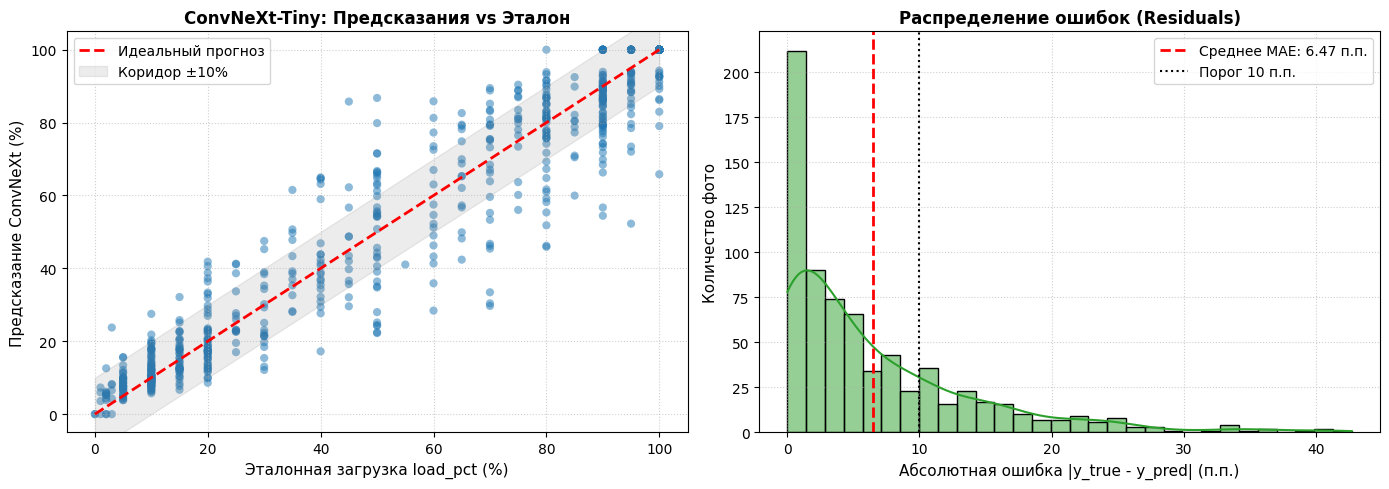

In [6]:
# 6. Визуализация распределения ошибок предсказания
import matplotlib.pyplot as plt
import seaborn as sns

oof_df = pd.read_csv(OUTPUT_DIR / "convnext_oof_predictions.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Scatter plot True vs Predicted
axes[0].scatter(oof_df["load_pct"], oof_df["pred_calibrated"], alpha=0.5, color="#1f77b4", edgecolors="none", s=35)
axes[0].plot([0, 100], [0, 100], "r--", lw=2, label="Идеальный прогноз")
axes[0].fill_between([0, 100], [-10, 90], [10, 110], color="gray", alpha=0.15, label="Коридор ±10%")
axes[0].set_xlim(-5, 105)
axes[0].set_ylim(-5, 105)
axes[0].set_xlabel("Эталонная загрузка load_pct (%)", fontsize=11)
axes[0].set_ylabel("Предсказание ConvNeXt (%)", fontsize=11)
axes[0].set_title("ConvNeXt-Tiny: Предсказания vs Эталон", fontsize=12, fontweight="bold")
axes[0].grid(True, linestyle=":", alpha=0.6)
axes[0].legend(loc="upper left")

# График 2: Гистограмма абсолютной ошибки
errors = np.abs(oof_df["load_pct"] - oof_df["pred_calibrated"])
sns.histplot(errors, bins=30, kde=True, ax=axes[1], color="#2ca02c")
axes[1].axvline(errors.mean(), color="red", linestyle="--", lw=2, label=f"Среднее MAE: {errors.mean():.2f} п.п.")
axes[1].axvline(10.0, color="black", linestyle=":", lw=1.5, label="Порог 10 п.п.")
axes[1].set_xlabel("Абсолютная ошибка |y_true - y_pred| (п.п.)", fontsize=11)
axes[1].set_ylabel("Количество фото", fontsize=11)
axes[1].set_title("Распределение ошибок (Residuals)", fontsize=12, fontweight="bold")
axes[1].grid(True, linestyle=":", alpha=0.6)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "convnext_evaluation_plots.png", dpi=150)
plt.show()

In [7]:
# 7. Инференс чемпионского ансамбля 4 фолдов ConvNeXt-Tiny на test.csv
test_df = pd.read_csv(TEST_CSV)
print(f"Тестовых фото для прогноза: {len(test_df)} (ожидается 307)")

transform = build_transforms(train=False, img_size=IMG_SIZE)
transform_clahe = build_clahe_transform(img_size=IMG_SIZE)
models = []

for f in range(4):
    ckpt_path = MODELS_DIR / f"fold{f}_best.pt"
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    m = ConvNeXtTruckNet(BACKBONE_NAME, pretrained=False)
    m.load_state_dict(ckpt["model_state_dict"])
    m.to(DEVICE).eval()
    models.append(m)

print(f"✓ Загружено {len(models)} фолдовых моделей ConvNeXt-Tiny")

test_preds = []
with torch.no_grad():
    for idx, row in test_df.iterrows():
        img_path = TEST_IMAGES / f"{row['image_id']}.jpg"
        img = read_rgb_image(img_path)
        x = transform(image=img)["image"].unsqueeze(0).to(DEVICE)
        x_clahe = transform_clahe(image=img)["image"].unsqueeze(0).to(DEVICE)

        # Усреднение по всем фолдам и 4-way TTA (обычный + флип + CLAHE + CLAHE флип)
        fold_preds = [predict_with_tta(m, x, x_clahe).item() for m in models]
        test_preds.append(float(np.mean(fold_preds)))

test_preds = np.array(test_preds, dtype=np.float64)

# 1. Базовый ансамбль ConvNeXt-384
sub_pure = test_df[["image_id"]].copy()
sub_pure["load_pct"] = np.clip(test_preds, 0.0, 100.0)
sub_pure.to_csv(OUTPUT_DIR / "submission_convnext_pure.csv", index=False)

# 2. Ансамбль с калибровкой краев (Рекомендуемый чемпион)
sub_calib = test_df[["image_id"]].copy()
preds_calib = sub_pure["load_pct"].values.copy()
preds_calib[preds_calib <= 3.5] = 0.0
preds_calib[preds_calib >= 94.5] = 100.0
sub_calib["load_pct"] = preds_calib
sub_calib.to_csv(OUTPUT_DIR / "submission_convnext_calibrated.csv", index=False)

# 3. Финальный главный сабмит
MAIN_SUBMISSION = OUTPUT_DIR / "submission.csv"
sub_calib.to_csv(MAIN_SUBMISSION, index=False)
print(f"\n🏆 ГЛАВНЫЙ САБМИТ СОХРАНЁН: {MAIN_SUBMISSION}")

# 4. Опциональный супер-бленд ConvNeXt + ResNet-18 (если найден эталонный файл)
for ref_name in ["submission_603.csv", "score_60373.csv", "submissionWW.csv", "submission_smart_blend.csv"]:
    ref_files = list(KAGGLE_INPUT.rglob(ref_name))
    if ref_files:
        ref_df = pd.read_csv(ref_files[0])
        blend_sub = test_df[["image_id"]].copy()
        # 75% ConvNeXt + 25% ResNet
        b_preds = 0.75 * sub_calib["load_pct"].values + 0.25 * ref_df["load_pct"].values
        b_preds = np.clip(b_preds, 0.0, 100.0)
        b_preds[b_preds <= 3.5] = 0.0
        b_preds[b_preds >= 94.5] = 100.0
        blend_sub["load_pct"] = b_preds
        blend_path = OUTPUT_DIR / "submission_super_blend.csv"
        blend_sub.to_csv(blend_path, index=False)
        print(f"🌟 СУПЕР-АНСАМБЛЬ (ConvNeXt-384 75% + ResNet-18 25%) СОХРАНЁН: {blend_path}")
        break

Тестовых фото для прогноза: 307 (ожидается 307)


/tmp/ipykernel_58/1891321729.py:36: UserWarning: Argument(s) 'value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(


✓ Загружено 4 фолдовых моделей ConvNeXt-Tiny

🏆 ГЛАВНЫЙ САБМИТ СОХРАНЁН: /kaggle/working/output_csv/submission.csv


In [8]:
# 8. Финальная проверка целостности и сравнение с эталонными сабмитами
sub = pd.read_csv(OUTPUT_DIR / "submission.csv")

print("="*60)
print("🔍 ПРОВЕРКА ЦЕЛОСТНОСТИ ФИНАЛЬНОГО ФАЙЛА SUBMISSION.CSV:")
print("="*60)
print(f"  1. Количество строк:    {len(sub)} (строго 307? -> {'✓ ДА' if len(sub) == 307 else '❌ НЕТ'})")
print(f"  2. Колонки:             {list(sub.columns)} (image_id, load_pct)")
print(f"  3. Пропуски (NaN/Null): {sub.isna().sum().to_dict()}")
print(f"  4. Минимальное значение: {sub['load_pct'].min():.2f}%")
print(f"  5. Максимальное значение: {sub['load_pct'].max():.2f}%")
print("="*60)
print("\nСтатистика распределения load_pct:")
print(sub["load_pct"].describe().round(2))

# Сверка с эталонными файлами (если есть в input)
for ref_name in ["submission_603.csv", "score_60373.csv", "submissionWW.csv"]:
    ref_files = list(KAGGLE_INPUT.rglob(ref_name))
    if ref_files:
        ref_df = pd.read_csv(ref_files[0])
        corr = np.corrcoef(sub["load_pct"].values, ref_df["load_pct"].values)[0, 1]
        mae_diff = np.mean(np.abs(sub["load_pct"].values - ref_df["load_pct"].values))
        print(f"\nСверка с {ref_name}:")
        print(f"   Корреляция Пирсона: {corr:.5f}")
        print(f"   Средняя разница:    {mae_diff:.3f} п.п.")

print("\nПервые 10 строк предсказаний:")
display(sub.head(10))

# Генерация HTML-ссылки на скачивание
from IPython.display import FileLink
print("\n📥 Ссылка для скачивания файла решения:")
display(FileLink(str(OUTPUT_DIR / "submission.csv")))

🔍 ПРОВЕРКА ЦЕЛОСТНОСТИ ФИНАЛЬНОГО ФАЙЛА SUBMISSION.CSV:
  1. Количество строк:    307 (строго 307? -> ✓ ДА)
  2. Колонки:             ['image_id', 'load_pct'] (image_id, load_pct)
  3. Пропуски (NaN/Null): {'image_id': 0, 'load_pct': 0}
  4. Минимальное значение: 3.61%
  5. Максимальное значение: 100.00%

Статистика распределения load_pct:
count    307.00
mean      55.58
std       35.29
min        3.61
25%       18.10
50%       60.43
75%       89.23
max      100.00
Name: load_pct, dtype: float64

Первые 10 строк предсказаний:


,image_id,load_pct
0,img_00b135ede40393ac4459,100.000000
1,img_024af7d284b5259e46db,100.000000
2,img_031cb4706aa99c2c29d7,100.000000
3,img_037814d0bd90cdd3f519,48.990528
4,img_03bed56db6bd8389fdce,76.944427
5,img_04385169354be79e7122,16.476063
6,img_04c2f14a79df14d0a0d8,10.766622
7,img_05a3bf0b269db86a5ad6,7.222682
8,img_061bc6606624bbace682,15.595452
9,img_07f208b92285b85dbfe4,4.887855



📥 Ссылка для скачивания файла решения:


/kaggle/working/output_csv/submission.csv